In [11]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from pathlib import Path

legend_properties = {'weight': 'bold'}

In [12]:
# Data folder
# Mac path for the Delegation experiment.
data_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4/Delegation_similarity")

# Must match `delegation_mode` in delegation_run.py: "random", "performance", or "similarity".
delegation_mode = "similarity"
output_prefix = delegation_mode + "_delegation"

delegation_rate_list_file = data_folder / (output_prefix + "_rate_list")
performance_file = data_folder / (output_prefix + "_performance")
diversity_file = data_folder / (output_prefix + "_diversity")
variance_file = data_folder / (output_prefix + "_variance")
consensus_performance_file = data_folder / (output_prefix + "_consensus_performance")

with open(delegation_rate_list_file, 'rb') as infile:
    delegation_rate_list = pickle.load(infile)
with open(performance_file, 'rb') as infile:
    delegation_performance = pickle.load(infile)
with open(diversity_file, 'rb') as infile:
    delegation_diversity = pickle.load(infile)
with open(variance_file, 'rb') as infile:
    delegation_variance = pickle.load(infile)
with open(consensus_performance_file, 'rb') as infile:
    delegation_consensus_performance = pickle.load(infile)

# Convert to arrays: shape = [len(delegation_rate_list), search_loop]
delegation_performance = np.array(delegation_performance)
delegation_diversity = np.array(delegation_diversity)
delegation_variance = np.array(delegation_variance)
delegation_consensus_performance = np.array(delegation_consensus_performance)
delegation_rate_array = np.array(delegation_rate_list)

print("delegation_mode:", delegation_mode)
print("delegation_rate_list:", delegation_rate_list)
print("performance shape:", delegation_performance.shape)
print("consensus performance shape:", delegation_consensus_performance.shape)


delegation_mode: similarity
delegation_rate_list: [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
performance shape: (10, 300)
consensus performance shape: (10, 300)


In [13]:
# Define more colors
# NUS two colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"
# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"
# Morandi six colors
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"
# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"

In [14]:
# Helper functions

def set_axis_style(ax):
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)


def final_value(matrix):
    """Return final-period value for each delegation level."""
    return np.array(matrix)[:, -1]


def window_average(matrix, window=50):
    """Return average over the last `window` periods for each delegation level."""
    matrix = np.array(matrix)
    return np.mean(matrix[:, -window:], axis=1)


def savefig(name):
    plt.savefig(data_folder / name, transparent=True, dpi=300, bbox_inches='tight')

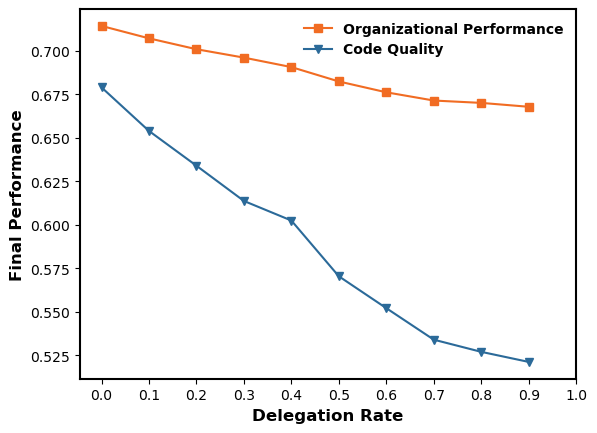

delegation list:  [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
performance list:  [0.7144152380952378, 0.7072715555555562, 0.701011238095238, 0.696179936507937, 0.6907359365079373, 0.6824673650793658, 0.6762326984126984, 0.6714962539682543, 0.670137650793651, 0.6679006984126983]
consensus performance list:  [0.6790666666666655, 0.6539999999999988, 0.6339999999999989, 0.6137333333333322, 0.6024666666666656, 0.5703999999999995, 0.5520666666666659, 0.5339333333333326, 0.5269333333333325, 0.5211333333333331]


<Figure size 640x480 with 0 Axes>

In [15]:
# Impact of delegation on final performance
order = np.argsort(delegation_rate_array)

x = delegation_rate_array[order]
individual_final = np.array(final_value(delegation_performance))[order]
consensus_final = np.array(final_value(delegation_consensus_performance))[order]

fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(x, individual_final, "-s", color=nature_orange,
        label="Organizational Performance")
ax.plot(x, consensus_final, "-v", color=nature_blue,
        label="Code Quality")

plt.xlabel(r'Delegation Rate', fontweight='bold', fontsize=12)
plt.ylabel('Final Performance', fontweight='bold', fontsize=12)
plt.xticks(np.arange(0, 1.01, 0.1))
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)

savefig("delegation_rate_final_performance.png")
plt.show()
plt.clf()

print("delegation list: ", x.tolist())
print("performance list: ", individual_final.tolist())
print("consensus performance list: ", consensus_final.tolist())

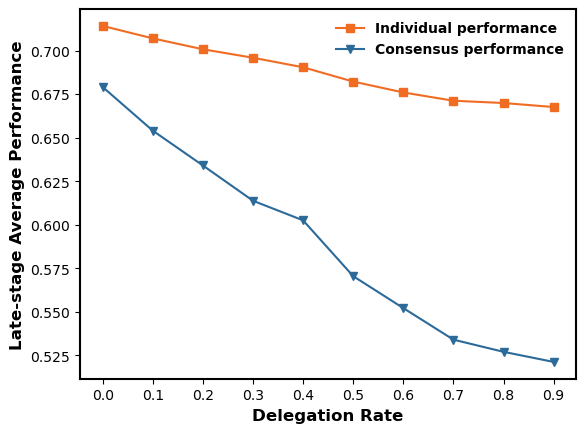

<Figure size 640x480 with 0 Axes>

In [16]:
# Impact of delegation on late-stage average performance
# This plot is less sensitive to final-period random fluctuation than the final-value plot.
window = 50
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(delegation_rate_array, window_average(delegation_performance, window=window), "-s",
        color=nature_orange, label="Individual performance")
ax.plot(delegation_rate_array, window_average(delegation_consensus_performance, window=window), "-v",
        color=nature_blue, label="Consensus performance")

plt.xlabel(r'Delegation Rate', fontweight='bold', fontsize=12)
plt.ylabel('Late-stage Average Performance', fontweight='bold', fontsize=12)
plt.xticks(delegation_rate_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("delegation_rate_late_stage_performance.png")
plt.show()
plt.clf()

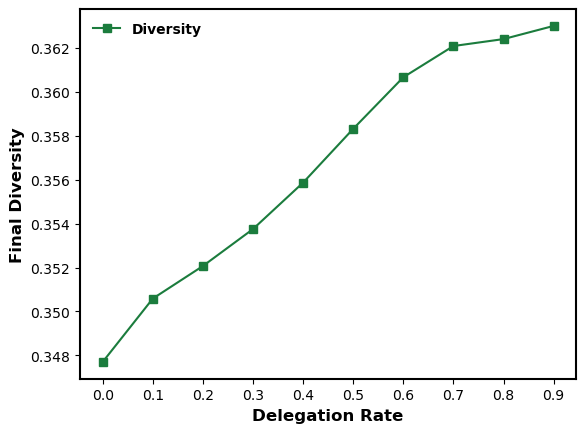

<Figure size 640x480 with 0 Axes>

In [17]:
# Impact of delegation on diversity
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(delegation_rate_array, final_value(delegation_diversity), "-s", color=nature_green,
        label="Diversity")

plt.xlabel(r'Delegation Rate', fontweight='bold', fontsize=12)
plt.ylabel('Final Diversity', fontweight='bold', fontsize=12)
plt.xticks(delegation_rate_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("delegation_rate_final_diversity.png")
plt.show()
plt.clf()

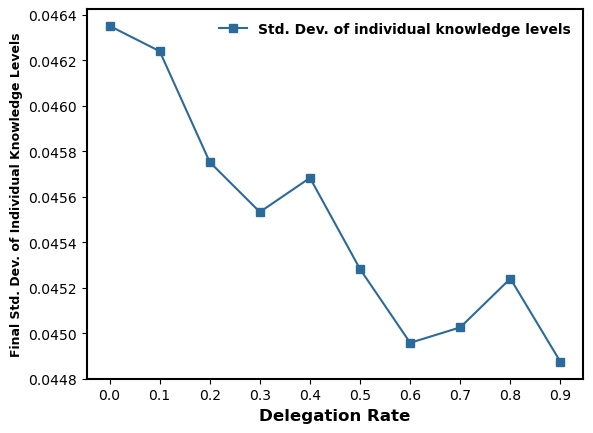

<Figure size 640x480 with 0 Axes>

In [18]:
# Impact of delegation on variance
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(delegation_rate_array, final_value(delegation_variance), "-s", color=nature_blue,
        label="Std. Dev. of individual knowledge levels")

plt.xlabel(r'Delegation Rate', fontweight='bold', fontsize=12)
plt.ylabel('Final Std. Dev. of Individual Knowledge Levels', fontweight='bold', fontsize=9)
plt.xticks(delegation_rate_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("delegation_rate_final_sd.png")
plt.show()
plt.clf()

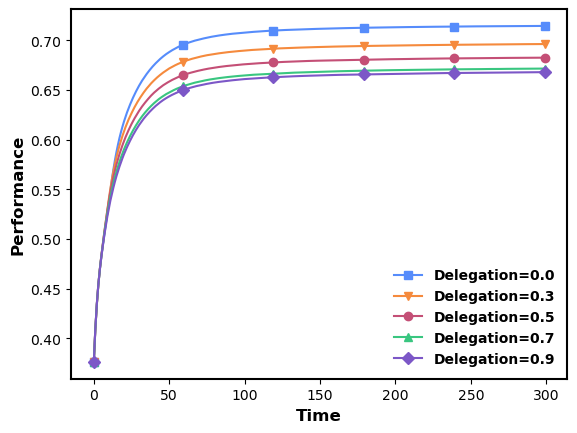

<Figure size 640x480 with 0 Axes>

In [19]:
# Time trajectories by selected delegation values
selected_delegation_rate_values = [0.0, 0.3, 0.5, 0.7, 0.9]
selected_indices = [int(np.argmin(np.abs(delegation_rate_array - delegation_rate))) for delegation_rate in selected_delegation_rate_values]
x = range(delegation_performance.shape[1])
marker_positions = np.linspace(0, len(x) - 1, num=6, dtype=int)

fig, ax = plt.subplots()
set_axis_style(ax)

markers = ["s", "v", "o", "^", "D"]
for idx, marker in zip(selected_indices, markers):
    ax.plot(x, delegation_performance[idx], "-" + marker,
            label=rf"Delegation={delegation_rate_array[idx]:.1f}",
            markevery=marker_positions)

plt.xlabel('Time', fontweight='bold', fontsize=12)
plt.ylabel('Performance', fontweight='bold', fontsize=12)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
# savefig("delegation_rate_performance_trajectories.png")
plt.show()
plt.clf()

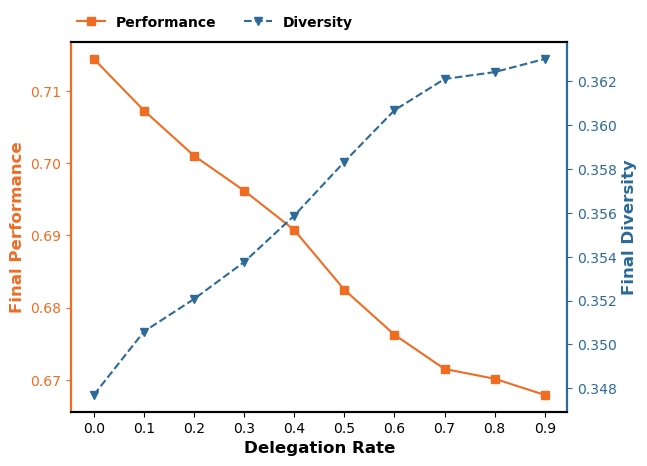

<Figure size 640x480 with 0 Axes>

In [20]:
# Twin plot: final performance and diversity across delegation
fig, ax1 = plt.subplots()
ax1.set_xlabel(r'Delegation Rate', fontweight='bold', fontsize=12)
ax1.set_ylabel('Final Performance', fontweight='bold', color="black", fontsize=12)

ax2 = ax1.twinx()
ax2.set_ylabel('Final Diversity', fontweight='bold', color="black", fontsize=12)

ax2.spines['left'].set_color(nature_orange)
ax1.yaxis.label.set_color(nature_orange)
ax1.tick_params(axis='y', colors=nature_orange)
ax2.spines['right'].set_color(nature_blue)
ax2.yaxis.label.set_color(nature_blue)
ax2.tick_params(axis='y', colors=nature_blue)

set_axis_style(ax1)
set_axis_style(ax2)

line_1 = ax1.plot(delegation_rate_array, final_value(delegation_performance), "-s",
                  label="Performance", color=nature_orange)
line_2 = ax2.plot(delegation_rate_array, final_value(delegation_diversity), "--v",
                  label="Diversity", color=nature_blue)

plt.xticks(delegation_rate_array)
lines = line_1 + line_2
labs = [line.get_label() for line in lines]
ax1.legend(lines, labs, frameon=False, fontsize=12, loc=(0, 1.02),
           ncol=2, prop=legend_properties)

savefig("delegation_rate_performance_diversity.png")
plt.show()
plt.clf()